#  **Energy Efficiency of Buildings - A Regression Approach**

<div style="text-align: justify">

#### In this study, we present a statistical machine learning framework designed to analyze the influence of ****eight input variables**** (relative compactness, surface area, wall area, roof area, overall height, orientation, glazing area, glazing area distribution) on ****two critical output variables**** : heating load (HL) and cooling load (CL) within residential buildings. Our investigation systematically assesses the strength of association between each input variable and the corresponding output variables through classical and non-parametric statistical analysis tools. This rigorous analysis aims to identify the most strongly correlated input variables. Subsequently, we employ both classical linear regression, a sophisticated nonlinear non-parametric method, ridge and lasso, random forests, for the estimation of HL and CL.

</div>


### **Importing the Data Set for Initial Analysis**

In [1]:
import pandas as pd
df = pd.read_excel('ENB2012_data.xlsx')

In [2]:
#To check the number of parameters and rows in the dataset
df.shape

(768, 10)

In [3]:
#check the parameters present in the dataset
df.head()


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [4]:
#check if there are any null items in the dataset
df.isnull().sum()


X1    0
X2    0
X3    0
X4    0
X5    0
X6    0
X7    0
X8    0
Y1    0
Y2    0
dtype: int64

In [5]:
#To check how varying the datsets is and if there are any outliers present in the dataset
df.describe()


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307195,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090204,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


In [6]:
X_df = df.drop(labels=['Y1','Y2'],axis=1)
X_df.head()

,X1,X2,X3,X4,X5,X6,X7,X8
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0


#### To Check the Correlation between Dependent and Independent variables, we have described and plotted the correlation between them.

In [7]:
#To check the correlation between Independent variables
X_df.corr()


,X1,X2,X3,X4,X5,X6,X7,X8
X1,1.000000e+00,-9.919015e-01,-2.037817e-01,-8.688234e-01,8.277473e-01,4.678592e-17,-2.960552e-15,-7.107006e-16
X2,-9.919015e-01,1.000000e+00,1.955016e-01,8.807195e-01,-8.581477e-01,-3.459372e-17,3.636925e-15,2.438409e-15
X3,-2.037817e-01,1.955016e-01,1.000000e+00,-2.923165e-01,2.809757e-01,-2.429499e-17,-8.567455e-17,2.067384e-16
X4,-8.688234e-01,8.807195e-01,-2.923165e-01,1.000000e+00,-9.725122e-01,-5.830058e-17,-1.759011e-15,-1.078071e-15
X5,8.277473e-01,-8.581477e-01,2.809757e-01,-9.725122e-01,1.000000e+00,4.492205e-17,1.489134e-17,-2.920613e-17
X6,4.678592e-17,-3.459372e-17,-2.429499e-17,-5.830058e-17,4.492205e-17,1.000000e+00,-9.406007e-16,-2.549352e-16
X7,-2.960552e-15,3.636925e-15,-8.567455e-17,-1.759011e-15,1.489134e-17,-9.406007e-16,1.000000e+00,2.129642e-01
X8,-7.107006e-16,2.438409e-15,2.067384e-16,-1.078071e-15,-2.920613e-17,-2.549352e-16,2.129642e-01,1.000000e+00


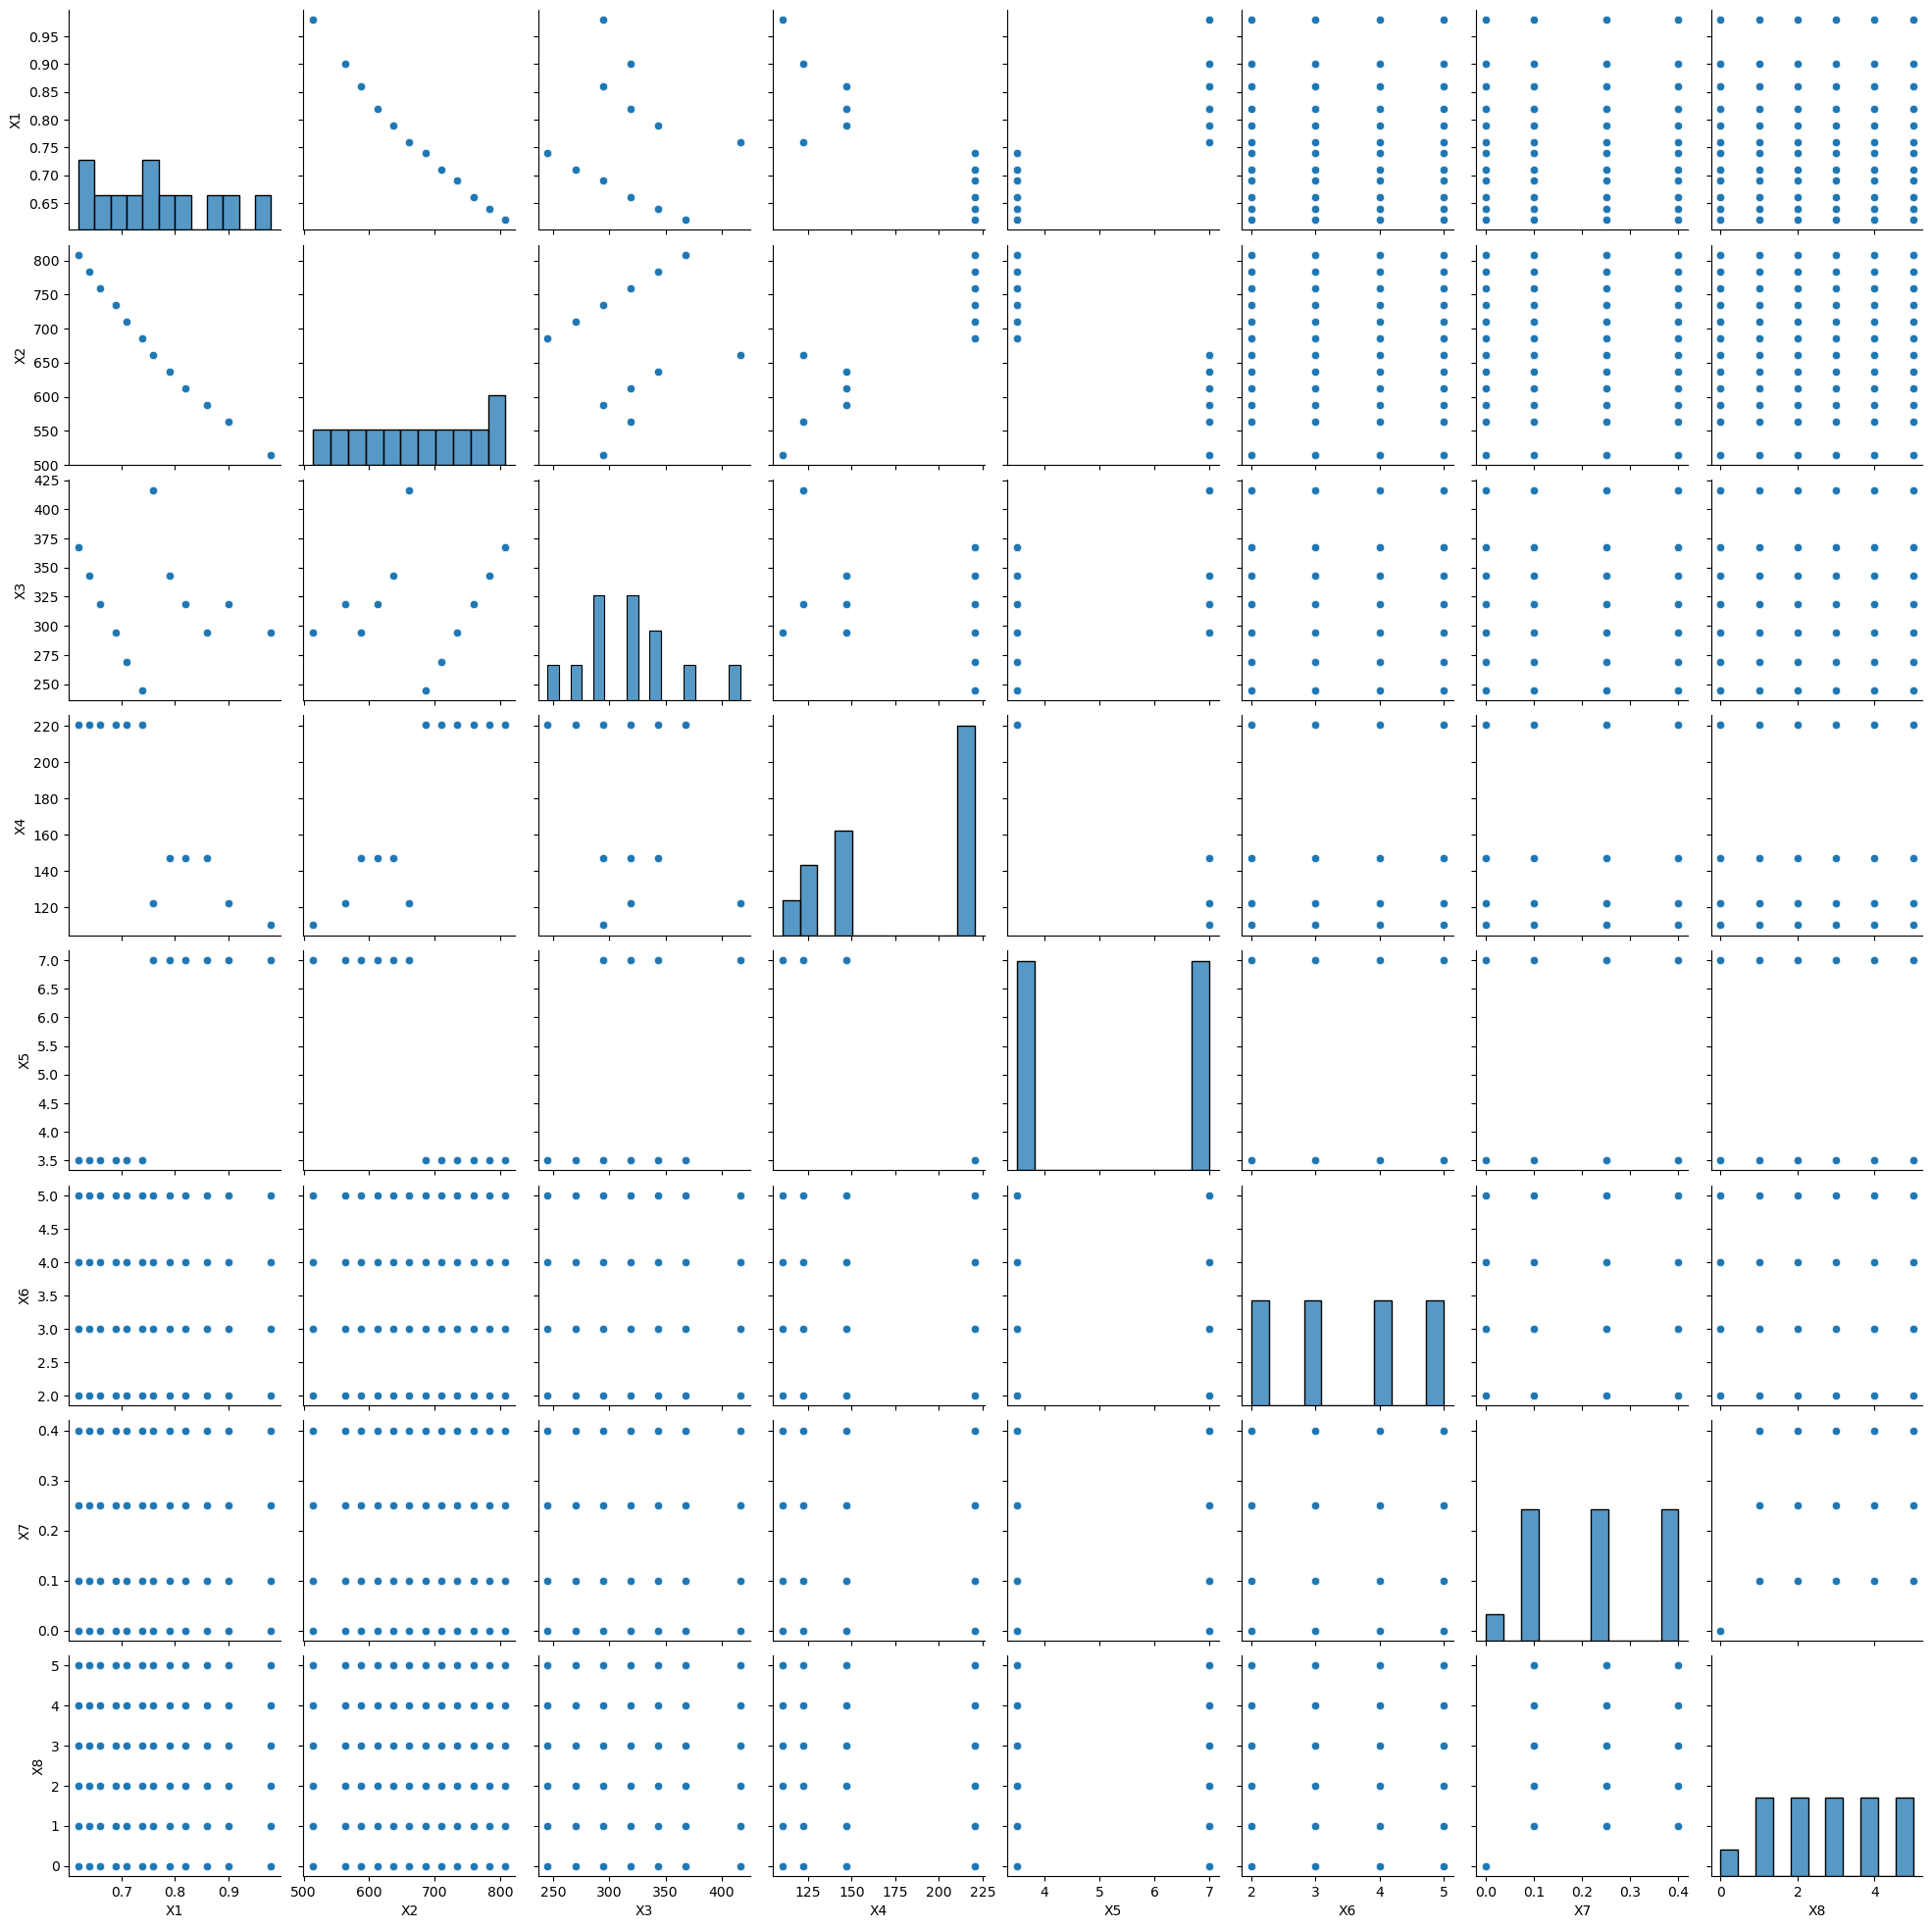

In [8]:
import warnings
import seaborn as sb

# Filter out the warning
warnings.filterwarnings("ignore", message="The figure layout has changed to tight", category=UserWarning)

#Created plots to compare correlation between Independent variables
sb.pairplot(X_df)



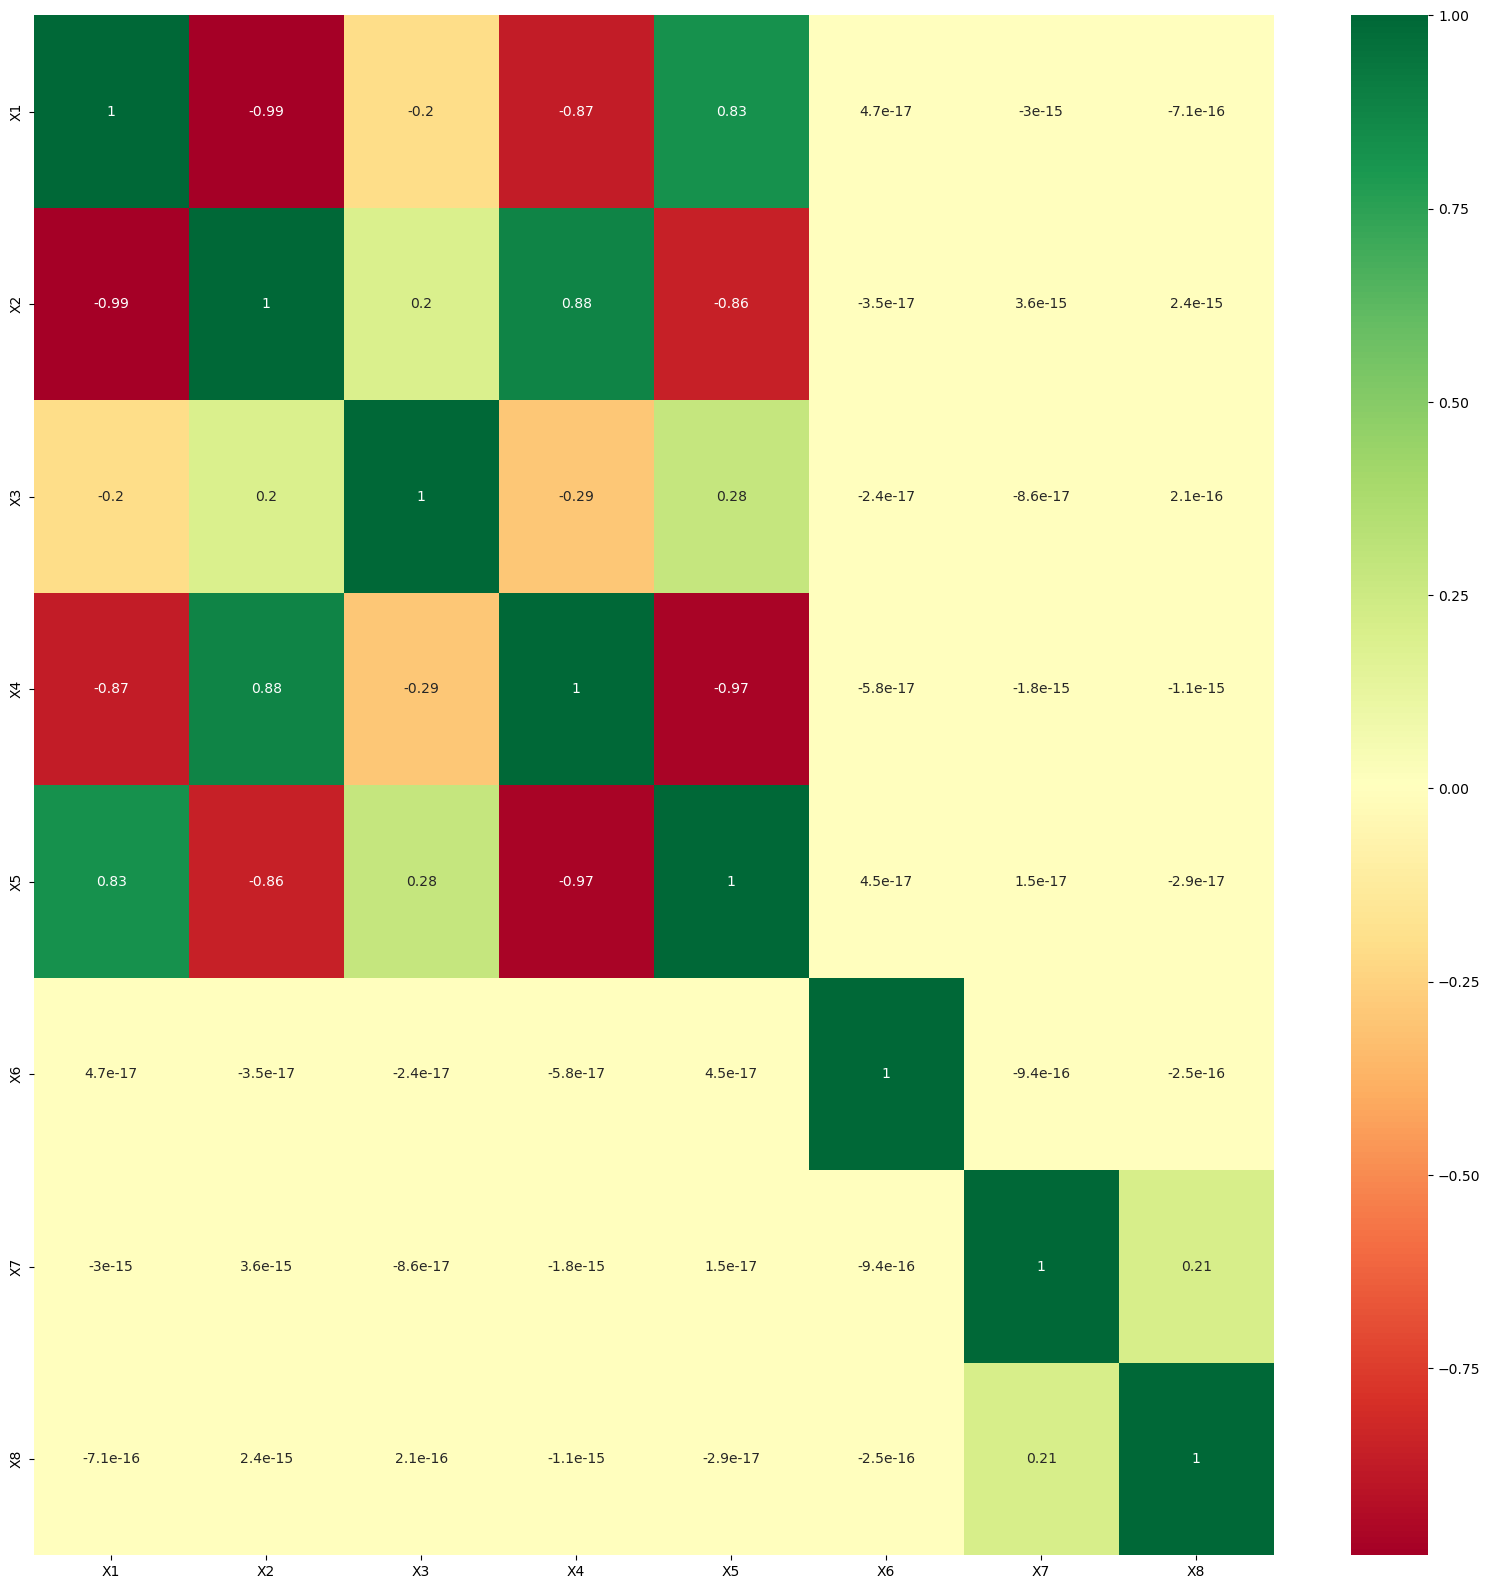

In [9]:
#Created heat plots to compare correlation between Independent variables more intuitively than the previous plots
import matplotlib.pyplot as plt
%matplotlib inline
corrmat=X_df.corr()
top_corr_features=corrmat.index
plt.figure(figsize=(20,20))
g=sb.heatmap(X_df[top_corr_features].corr(),annot=True,cmap="RdYlGn")


In [10]:
#Computing correlation between all the variables
df.corr()


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
X1,1.000000e+00,-9.919015e-01,-2.037817e-01,-8.688234e-01,8.277473e-01,4.678592e-17,-2.960552e-15,-7.107006e-16,0.622272,0.634339
X2,-9.919015e-01,1.000000e+00,1.955016e-01,8.807195e-01,-8.581477e-01,-3.459372e-17,3.636925e-15,2.438409e-15,-0.658120,-0.672999
X3,-2.037817e-01,1.955016e-01,1.000000e+00,-2.923165e-01,2.809757e-01,-2.429499e-17,-8.567455e-17,2.067384e-16,0.455671,0.427117
X4,-8.688234e-01,8.807195e-01,-2.923165e-01,1.000000e+00,-9.725122e-01,-5.830058e-17,-1.759011e-15,-1.078071e-15,-0.861828,-0.862547
X5,8.277473e-01,-8.581477e-01,2.809757e-01,-9.725122e-01,1.000000e+00,4.492205e-17,1.489134e-17,-2.920613e-17,0.889430,0.895785
X6,4.678592e-17,-3.459372e-17,-2.429499e-17,-5.830058e-17,4.492205e-17,1.000000e+00,-9.406007e-16,-2.549352e-16,-0.002587,0.014290
X7,-2.960552e-15,3.636925e-15,-8.567455e-17,-1.759011e-15,1.489134e-17,-9.406007e-16,1.000000e+00,2.129642e-01,0.269842,0.207505
X8,-7.107006e-16,2.438409e-15,2.067384e-16,-1.078071e-15,-2.920613e-17,-2.549352e-16,2.129642e-01,1.000000e+00,0.087368,0.050525
Y1,6.222719e-01,-6.581199e-01,4.556714e-01,-8.618281e-01,8.894305e-01,-2.586763e-03,2.698417e-01,8.736846e-02,1.000000,0.975862
Y2,6.343391e-01,-6.729989e-01,4.271170e-01,-8.625466e-01,8.957852e-01,1.428960e-02,2.075050e-01,5.052512e-02,0.975862,1.000000


<div style="text-align: justify">

#### We can see that X1, X2, X3, X4, X5 and X7 have more significance on Y1 & Y2 than X6 and X8 to Y1 and Y2 from the Heat Map and from the correlation table as well.

</div>

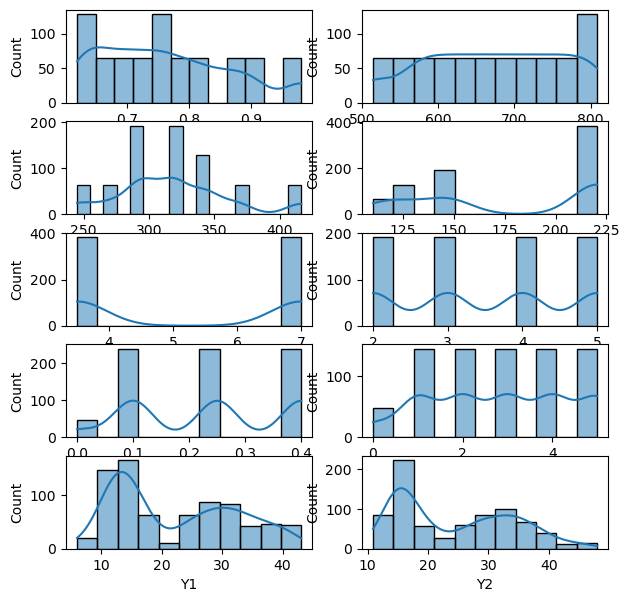

In [11]:
#Checking the distribution of all the variables(Independent & Dependent)
fig, axs = plt.subplots(5, 2, figsize=(7, 7))
sb.histplot(data=df, x="X1", kde=True, ax=axs[0, 0])
sb.histplot(data=df, x="X2", kde=True, ax=axs[0, 1])
sb.histplot(data=df, x="X3", kde=True, ax=axs[1, 0])
sb.histplot(data=df, x="X4", kde=True, ax=axs[1, 1])
sb.histplot(data=df, x="X5", kde=True, ax=axs[2, 0])
sb.histplot(data=df, x="X6", kde=True, ax=axs[2, 1])
sb.histplot(data=df, x="X7", kde=True, ax=axs[3, 0])
sb.histplot(data=df, x="X8", kde=True, ax=axs[3, 1])
sb.histplot(data=df, x="Y1", kde=True, ax=axs[4, 0])
sb.histplot(data=df, x="Y2", kde=True, ax=axs[4, 1])
plt.show()

#### We can also observe from the above given Histogram plot that none of the Independent variables follows any kind of Distribution in particular, but some of them have a slight resemblance to Normal Distribution.

## **Training Testing and Model Evaluation**

<div style="text-align: justify">

##### After carefully understanding and transforming the data as per needs we have decided to train and test the data set to predict the Energy Efficiency of these Buildings using three different Machine Learning(ML) Algorithms. We would be having a closer look at Random Forest Regression, Ridge and Lasso as well as Polynomial Regression in the below given sections.

</div>

### **Random Forest Regression**
<div style="text-align: justify">

##### We have used a Random Forest Regressor as our first model for predicting the heating and cooling coefficients of the building. Randomized Search Cross-Validation is performed to find the best hyperparameters for the Random Forest model. Once we have found the best hyperparameters using above technique, we have trained the model on training data (which we have split from the main data) with the best hyperparameters. We have made final predictions based on the trained model and checked model's accuracy using the R<sup>2</sup> score, which measures the goodness of fit of the model to the test data.

</div>

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END max_depth=25, max_features=2, min_samples_leaf=5, min_samples_split=15, n_estimators=1100; total time=   0.9s
[CV] END max_depth=25, max_features=2, min_samples_leaf=5, min_samples_split=15, n_estimators=1100; total time=   1.0s
[CV] END max_depth=25, max_features=2, min_samples_leaf=5, min_samples_split=15, n_estimators=1100; total time=   1.0s
[CV] END max_depth=25, max_features=2, min_samples_leaf=5, min_samples_split=15, n_estimators=1100; total time=   0.9s
[CV] END max_depth=25, max_features=2, min_samples_leaf=5, min_samples_split=15, n_estimators=1100; total time=   0.9s
[CV] END max_depth=20, max_features=2, min_samples_leaf=5, min_samples_split=5, n_estimators=900; total time=   0.7s
[CV] END max_depth=20, max_features=2, min_samples_leaf=5, min_samples_split=5, n_estimators=900; total time=   0.7s
[CV] END max_depth=20, max_features=2, min_samples_leaf=5, min_samples_split=5, n_estimators=900; total time= 

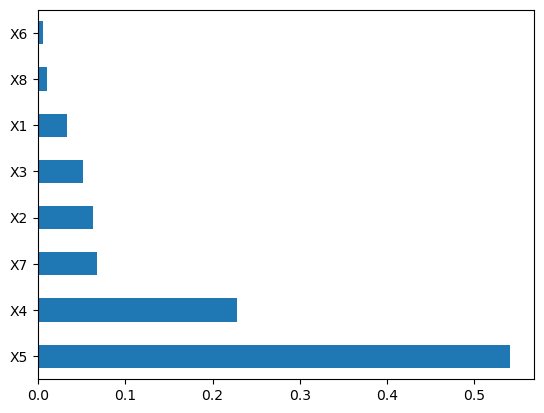

In [12]:
# Standardize features
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler,scale
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt

# Scaling the features
scaler = StandardScaler()
X = df[['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']]
X_scaled = scale(X)

# Concatenate Y1 and Y2 into a single target variable
y = np.concatenate((df[['Y1']], df[['Y2']]), axis=1)

'''Feature Importance Analysis, used to see which features are more relevant to predict y1 & y2.
It is basically a relative score among features, which calculates summation of all node importances that split on a particular feature k upon summation of all node importances.
We can see the outuput of feature importance in a bar chart below this chunk'''
model = ExtraTreesRegressor()
model.fit(X, y)
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(8).plot(kind='barh')

# Drop features with low importance - X6 and X8
X = df[['X1', 'X2', 'X3', 'X4', 'X5', 'X7']]


# Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Define the Random Forest model
rf = RandomForestRegressor()

# Define hyperparameters for RandomizedSearchCV
n_estimators = [int(x) for x in np.linspace(start=100, stop=1200, num=12)]
max_features = [2]
max_depth = [int(x) for x in np.linspace(5, 30, num=6)]
min_samples_split = [2, 5, 10, 15, 100]
min_samples_leaf = [1, 2, 5, 10]

random_grid = {
    'n_estimators': n_estimators,
    'max_features': max_features,
    'max_depth': max_depth,
    'min_samples_split': min_samples_split,
    'min_samples_leaf': min_samples_leaf
}

# Perform Randomized Search CV
rf_random = RandomizedSearchCV(estimator=rf, param_distributions=random_grid, 
                               scoring='neg_mean_squared_error', n_iter=10, cv=5, 
                               verbose=2, random_state=42, n_jobs=1)

# Train the model
rf_random.fit(x_train, y_train)

# Make predictions
predictions = rf_random.predict(x_test)

# Evaluate the model
r2_scores = r2_score(y_test, predictions, multioutput='raw_values')
print("R-squared for Random forest Regression model (y1, y2):", r2_scores)

#### The Bar Graph depicted above, also adds on to the fact that features X6 and X8 are not significant for estimating HL and CL and can be neglected.

### **Ridge Regression**

<div style="text-align: justify">

#### In our research, we employed a 10-fold cross-validation method to determine the optimal hyperparameter alpha(α) in the context of Ridge regression. For Lasso regression, we utilized a nested cross-validation approach to identify the appropriate α, also known as the learning rate. Acknowledging the sensitivity of Lasso regression to feature scaling, we meticulously standardized both the training and testing datasets. It is noteworthy that despite this scaling, Lasso did not eliminate any features.

#### Upon conducting our analyses, we observed a convergence of results between Ridge and Lasso regression for the current dataset. This convergence implies a parity in the predictive performance of both regression techniques, underscoring their comparable effectiveness within the scope of our study.

</div>

In [13]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

gandata = df

X = gandata[['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']]
y = gandata[['Y1', 'Y2']]

#Alpha Selection using 10 fold cross Validation
alphas = np.logspace(-4, 4, 9)
cv_scores = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    scores = cross_val_score(ridge, X, y, cv=10)
    mean_score = np.mean(scores)
    cv_scores.append(mean_score)

best_alpha_index = np.argmax(cv_scores)
best_alpha = alphas[best_alpha_index]
print("Best alpha :", best_alpha)

#Ridge Model for Predictions with Best Alpha
ridge = Ridge(alpha=best_alpha)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
ridge.fit(X_train, y_train)
predictions = ridge.predict(X_test)
mse = np.mean((predictions - y_test)**2)
print("Mean Squared Error:", mse)

r2_scores = r2_score(y_test, predictions, multioutput='raw_values')

print("R-squared for Ridge Regression model (y1, y2):", r2_scores)



Best alpha : 0.001
Mean Squared Error: 9.524741396750887
R-squared for Ridge Regression model (y1, y2): [0.91215555 0.89322751]


### **Lasso Regression**

In [14]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score


gandata = df
X = gandata[['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']]
y = gandata[['Y1', 'Y2']]

#Scaling Data as Lasso is very sensitive to scale of the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Using Nested Validation to find the alpha using GridSearchCV
lasso = Lasso(max_iter=10000)
alphas = np.logspace(-4, 4, 9)
param_grid = {'alpha': alphas}
inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(estimator=lasso, param_grid=param_grid, cv=inner_cv, scoring='r2')
grid_search.fit(X_scaled, y)
best_alpha = grid_search.best_params_['alpha']
print("Best alpha:", best_alpha)

#Lasso Model for Predictions
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
lasso = Lasso(alpha=best_alpha)
lasso.fit(X_train_scaled, y_train)
predictions = lasso.predict(X_test_scaled)
r2_scores = r2_score(y_test, predictions, multioutput='raw_values')

print("R-squared for Lasso Regression model (y1, y2):", r2_scores)

Best alpha: 0.001
R-squared for Lasso Regression model (y1, y2): [0.9121369  0.89321687]


### **Polynomial Regression**
<div style="text-align: justify">

#### Given the relatively diminished model accuracy achieved by Ridge and Lasso regressions, it is prudent to conduct a preliminary assessment using Linear Regression before delving into Polynomial Regression. This step allows us to establish a baseline performance and validate the need for more complex models. Also, we are trying to analyse the Backward Stepwise feature selection technique first and then compare it with the features which were selected using correlation.

#### Subsequently, we will proceed with Polynomial Regression, opting for a polynomial degree of 2. This decision is grounded in the consideration that an increase in polynomial degree heightens the risk of overfitting the model to the training data.


</div>

#### **Backward Stepwise Feature Selection**

In [15]:
from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

gandata = df.copy()

X = gandata[['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']]
y = gandata[['Y1', 'Y2']]

#normalising all the parameters
X_scaled = scale(X)


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Polynomial features degree is set as two, as an Intermediary between higher polynomial degrees
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

polyr = LinearRegression()
polyr.fit(X_train_poly, y_train)

# Sequential backward selection (sbs) 
sbs = SequentialFeatureSelector(LinearRegression(),
                                k_features='best',  # Select the best subset of features
                                forward=False,      # Foward equals false meaning - Backwards
                                floating=False,
                                cv=0)

sbs.fit(X_train_poly, y_train)

# Get the selected feature indices and ensure they are within bounds
selected_feature_indices = np.ravel(sbs.k_feature_idx_)
selected_feature_indices = selected_feature_indices[selected_feature_indices < X.shape[1]]

# Get the selected feature names from original features
selected_feature_names = list(X.columns[selected_feature_indices])

# Print the selected features
print("Selected features:", selected_feature_names)


Selected features: ['X1', 'X2', 'X5', 'X6', 'X7', 'X8']


<div style="text-align: justify">

#### The above features X1, X2, X5, X6, X7 and X8 were selected by using the Backward Stepwise Feature Selection for Polynomial Regression. We can perform evaluation of R<sup>2</sup> score on the model obtained by using the Selected features.


</div>

In [16]:
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

X = gandata[['X1', 'X2', 'X5', 'X6', 'X7', 'X8']]
y = df[['Y1', 'Y2']]

#normalising all the parameters
X_scaled = scale(X)


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

#Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

predictions = lr.predict(X_test)

r2_scoreslinear = r2_score(y_test, predictions, multioutput='raw_values')

print("R-squared score for Linear Regression using Backward Stepwise Feature Selection is :", r2_scoreslinear)

#Polynomial Regression
# Polynomial features degree is set as two, as an Intermediary between higher polynomial degrees

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

polyr = LinearRegression()
polyr.fit(X_train_poly, y_train)

# Predictions
predictions_poly = polyr.predict(X_test_poly)


#Evaluation of R2 Scores
r2_polyr_test = r2_score(y_test, predictions_poly,multioutput='raw_values')

print("R-squared score for Polynomial Regression using Backward Stepwise Feature Selection is :", r2_polyr_test)

# Perform K Fold cross-validation - chose value of fold as 5 because its generally taken as 5.
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_polyr = cross_val_score(polyr, X_train_poly, y_train, cv=kf, scoring='r2')

print("Cross-validated R-squared scores for Polynomial Regression using Backward Stepwise Feature Selection is:", np.mean(cv_scores_polyr))

R-squared score for Linear Regression using Backward Stepwise Feature Selection is : [0.90403706 0.8923401 ]
R-squared score for Polynomial Regression using Backward Stepwise Feature Selection is : [0.94618499 0.91321337]
Cross-validated R-squared scores for Polynomial Regression using Backward Stepwise Feature Selection is: 0.9324531610595252


#### **Feature Selection using Correlation**

In [17]:
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
import numpy as np


gandata = df.copy()

#removed X6 and X8 as their importance is low found using correlation between dependent and independent variables
X = gandata[['X1', 'X2', 'X3', 'X4', 'X5', 'X7']]
y = gandata[['Y1', 'Y2']]

y = df[['Y1', 'Y2']]


#normalising all the parameters
X_scaled = scale(X)


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

#Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

predictions = lr.predict(X_test)

r2_scoreslinear = r2_score(y_test, predictions, multioutput='raw_values')
print("R-squared score for Linear Regression using correlation as feature selection is:", r2_scoreslinear)

#Polynomial Regression
# Polynomial features degree is set as two, as an Intermediary between higher polynomial degrees

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

polyr = LinearRegression()
polyr.fit(X_train_poly, y_train)

# Predictions
predictions_poly = polyr.predict(X_test_poly)


#Evaluation of R2 Score
r2_polyr_test = r2_score(y_test, predictions_poly,multioutput='raw_values')

print("R-squared score for Polynomial Regression using correlation as feature selection is:", r2_polyr_test)

# Perform K Fold cross-validation - chose value of fold as 5 because its generally taken as 5.
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_polyr = cross_val_score(polyr, X_train_poly, y_train, cv=kf, scoring='r2')

print("Cross-validated R-squared scores for Polynomial Regression using correlation as feature selection is:", np.mean(cv_scores_polyr))


R-squared score for Linear Regression using correlation as feature selection is: [0.91156393 0.89256961]
R-squared score for Polynomial Regression using correlation as feature selection is: [0.99115176 0.96779771]
Cross-validated R-squared scores for Polynomial Regression using correlation as feature selection is: 0.9806307593068444


<div style="text-align: justify">

#### As observed, the features selected using Correlation performs much better than the ones selected using Backward Stepwise feature selection for the given dataset when using Polynomial Regression. Even proven so by using the K-fold cross validation(cv).

</div>

## **Conclusion and Future Development**
<div style="text-align: justify">

##### We have got high accuracy (R2 values) for Random forest regression model (0.99,0.97) followed by Polynomial regression model(0.99 & 0.96) and got least accuracy for Lasso and Ridge regression models (0.91 & 0.89). We have used randomized  search cross validation to fine tune the parameters used in random forest model, 10 fold cv for Lasso, nested cv for Ridge regression and 5 fold cv for Polynomial Regression.
##### We can improve the random forest model by creating multiple instances of parameter values and performing a randomized search cv on each of them and thus obtaining the best lot of hyper parameters to make the results more fine tuned.
    
</div>